In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [4]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Data Understanding

In [5]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.81

# Data Processing


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode target column if needed
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# K-Means Clustering

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

print(df['Cluster'].value_counts())

Cluster
2    91
0    68
1     8
Name: count, dtype: int64


# DBSCAN Clustering

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    144
-1     23
Name: count, dtype: int64


# Create Classification Target

In [15]:
X = scaled_data
y = df['Cluster']

# Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 0.9411764705882353


# XGBoost Classifier

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8823529411764706


# Evaluation

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      1.00      1.00         2
           2       1.00      0.90      0.95        20

    accuracy                           0.94        34
   macro avg       0.95      0.97      0.96        34
weighted avg       0.95      0.94      0.94        34

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.50      0.67         2
           2       0.94      0.85      0.89        20

    accuracy                           0.88        34
   macro avg       0.91      0.78      0.82        34
weighted avg       0.90      0.88      0.88        34



# Visualization

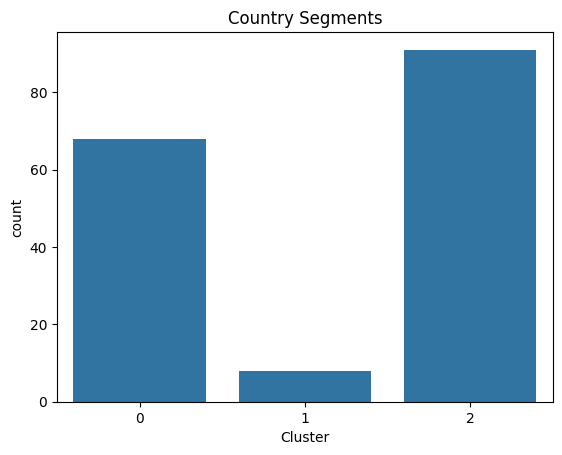

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Cluster', data=df)
plt.title("Country Segments")
plt.show()

# Resume Description

**Customer Intelligence System using Classification, Ensemble Learning & Clustering**

- Built an end-to-end machine learning pipeline on country socio-economic data.
- Applied K-Means and DBSCAN to identify meaningful country segments.
- Developed predictive models using Random Forest and XGBoost to classify countries into cluster groups.
- Performed feature scaling, exploratory data analysis, model evaluation, and visualization.
- Achieved high classification accuracy through ensemble learning techniques and generated actionable segmentation insights for decision-making.